# Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tracking = pd.read_csv("tracking.csv", index_col=0)
tracking.head()

,Date,High_Accel,High_Decel,Distance,Player
1,12/17/23,42,21,1.570448,Jeremy Onion
2,12/18/23,34,12,1.085810,Jeremy Onion
3,1/22/24,42,14,1.100427,Jeremy Onion
4,10/14/23,21,21,1.570543,Jeremy Onion
5,12/1/23,19,20,1.359779,Jeremy Onion


In [2]:
force_plate = pd.read_csv("force_plate.csv", index_col=0)
force_plate.head()

,Date,Peak_Eccentric_Force,Peak_Concentric_Force,Jump_Height,Leg,Player
1,12/17/23,1566.099167,2073.849826,8.110429,Left,Jeremy Onion
2,12/18/23,1455.454844,2112.158204,6.232270,Left,Jeremy Onion
3,1/22/24,1609.136074,2089.475731,8.523894,Left,Jeremy Onion
4,10/14/23,1662.662397,1959.669040,6.901727,Left,Jeremy Onion
5,12/1/23,1496.100033,1839.778200,7.707496,Left,Jeremy Onion


In [3]:
schedule = pd.read_csv("schedule.csv", index_col=0)
schedule.head()

,Date,Type
1,12/17/23,Practice
2,12/18/23,Game
3,1/22/24,Game
4,10/14/23,Practice
5,12/1/23,Game


# Exploratory Data Analysis

**Outline**
1. Structure
2. Players
3. Missing values & data-quality checks
4. Distributions & Correlation
5. Notes and Findings

## 1. Structure

In [4]:
for name, df in [("tracking", tracking), ("force_plate", force_plate), ("schedule", schedule)]:
    print(f"- {name} -")
    print("shape  :", df.shape)
    print("columns:", list(df.columns))
    print(df.dtypes.to_string())
    print()

- tracking -
shape  : (600, 5)
columns: ['Date', 'High_Accel', 'High_Decel', 'Distance', 'Player']
Date           object
High_Accel      int64
High_Decel      int64
Distance      float64
Player         object

- force_plate -
shape  : (1200, 6)
columns: ['Date', 'Peak_Eccentric_Force', 'Peak_Concentric_Force', 'Jump_Height', 'Leg', 'Player']
Date                      object
Peak_Eccentric_Force     float64
Peak_Concentric_Force    float64
Jump_Height              float64
Leg                       object
Player                    object

- schedule -
shape  : (100, 2)
columns: ['Date', 'Type']
Date    object
Type    object



In [5]:
# Parse the Date column in all three tables from M/D/YY strings to real datetimes
for df in (tracking, force_plate, schedule):
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")

print("Season span:", tracking["Date"].min().date(), "->", tracking["Date"].max().date())
print("Unique dates:", tracking["Date"].nunique())
tracking.dtypes

Season span: 2023-10-05 -> 2024-06-20
Unique dates: 100


Date          datetime64[ns]
High_Accel             int64
High_Decel             int64
Distance             float64
Player                object
dtype: object

## 2. Players

In [6]:
trk_players = set(tracking["Player"].unique())
fp_players  = set(force_plate["Player"].unique())

print("Players in tracking   :", len(trk_players))
print("Players in force_plate:", len(fp_players))
print("Total unique players  :", len(trk_players | fp_players))

Players in tracking   : 6
Players in force_plate: 6
Total unique players  : 7


In [7]:
print("In BOTH tables      :", sorted(trk_players & fp_players))
print("ONLY in tracking    :", sorted(trk_players - fp_players))
print("ONLY in force_plate :", sorted(fp_players - trk_players))

In BOTH tables      : ['Charlie Broccoli', 'Jeremy Onion', 'Joey Mushroom', 'Scott Kale', 'Trey Cabbage']
ONLY in tracking    : ['Mark Parsley']
ONLY in force_plate : ['Kyle Garlick']


In [8]:
print("Rows per player (tracking):")
print(tracking["Player"].value_counts().to_string())

Rows per player (tracking):
Player
Jeremy Onion        100
Charlie Broccoli    100
Trey Cabbage        100
Joey Mushroom       100
Scott Kale          100
Mark Parsley        100


In [9]:
print("Rows per (player, leg) (force_plate):")
print(force_plate.groupby(["Player", "Leg"]).size().to_string())

Rows per (player, leg) (force_plate):
Player            Leg  
Charlie Broccoli  Left     100
                  Right    100
Jeremy Onion      Left     100
                  Right    100
Joey Mushroom     Left     100
                  Right    100
Kyle Garlick      Left     100
                  Right    100
Scott Kale        Left     100
                  Right    100
Trey Cabbage      Left     100
                  Right    100


## 3. Missing values & data-quality checks

In [10]:
# 1) Literal missing values (NaN)
print("Total NaNs per table")
for name, df in [("tracking", tracking), ("force_plate", force_plate), ("schedule", schedule)]:
    print(f"  {name:12s}: {int(df.isna().sum().sum())}")

# 2) Duplicate records at the expected grain
print("\nDuplicate rows at natural grain")
print("  tracking (Player, Date)       :", int(tracking.duplicated(["Player", "Date"]).sum()))
print("  force_plate (Player,Date,Leg) :", int(force_plate.duplicated(["Player", "Date", "Leg"]).sum()))

# 3) Impossible / out-of-range values (domain sanity checks)
print("\nDomain / sanity checks")
print("  High_Accel < 0 :", int((tracking["High_Accel"] < 0).sum()))
print("  High_Decel < 0 :", int((tracking["High_Decel"] < 0).sum()))
print("  Distance <= 0  :", int((tracking["Distance"] <= 0).sum()))
print("  Jump_Height<=0 :", int((force_plate["Jump_Height"] <= 0).sum()))
print("  Forces <= 0    :", int((force_plate[["Peak_Eccentric_Force", "Peak_Concentric_Force"]] <= 0).sum().sum()))

Total NaNs per table
  tracking    : 0
  force_plate : 0
  schedule    : 0

Duplicate rows at natural grain
  tracking (Player, Date)       : 0
  force_plate (Player,Date,Leg) : 0

Domain / sanity checks
  High_Accel < 0 : 0
  High_Decel < 0 : 1
  Distance <= 0  : 0
  Jump_Height<=0 : 0
  Forces <= 0    : 0


## 4. Distributions & Correlation

### Workload vs. Force-Plate

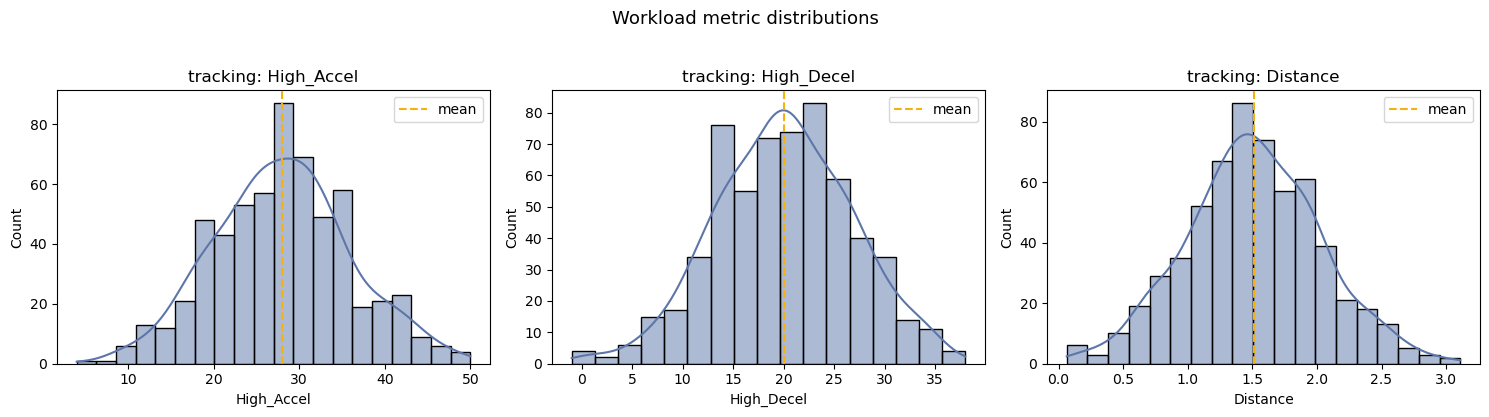

In [11]:
# Workload metrics
cols = ["High_Accel", "High_Decel", "Distance"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cols):
    sns.histplot(tracking[col], kde=True, ax=ax, color="#5D76A9")
    ax.axvline(tracking[col].mean(), color="#F5B112", ls="--", lw=1.5, label="mean")
    ax.set_title(f"tracking: {col}")
    ax.legend()
fig.suptitle("Workload metric distributions", y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

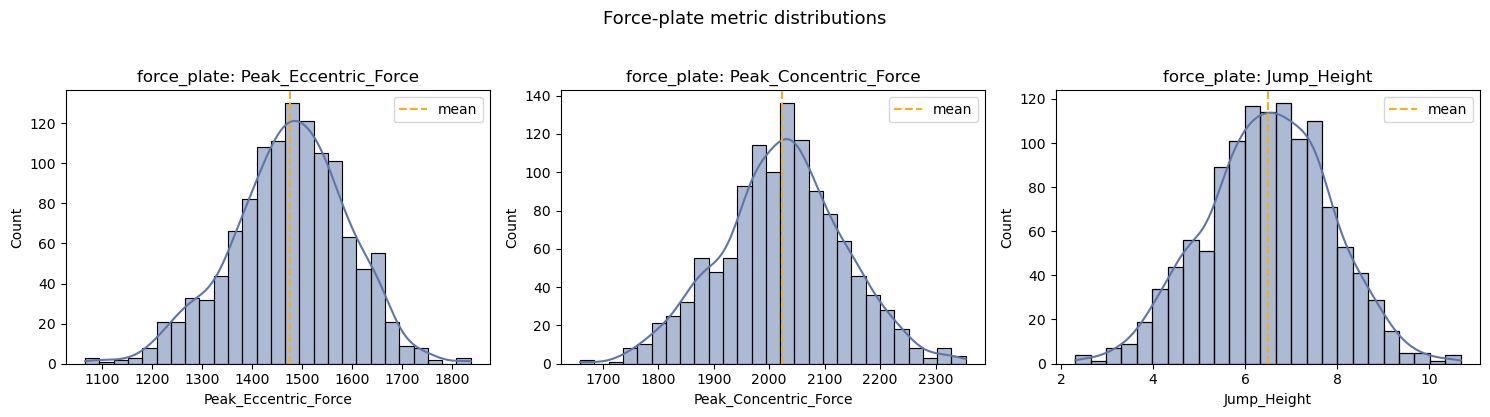

In [12]:
# Force-plate metrics
cols = ["Peak_Eccentric_Force", "Peak_Concentric_Force", "Jump_Height"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cols):
    sns.histplot(force_plate[col], kde=True, ax=ax, color="#5D76A9")
    ax.axvline(force_plate[col].mean(), color="#F5B112", ls="--", lw=1.5, label="mean")
    ax.set_title(f"force_plate: {col}")
    ax.legend()
fig.suptitle("Force-plate metric distributions", y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

In [13]:
display(tracking[["High_Accel", "High_Decel", "Distance"]].describe().round(2))
display(force_plate[["Peak_Eccentric_Force", "Peak_Concentric_Force", "Jump_Height"]].describe().round(2))

,High_Accel,High_Decel,Distance
count,600.00,600.00,600.00
mean,28.00,20.05,1.51
std,7.95,6.76,0.52
min,4.00,-1.00,0.06
25%,23.00,15.00,1.17
50%,28.00,20.00,1.50
75%,33.00,25.00,1.86
max,50.00,38.00,3.11


,Peak_Eccentric_Force,Peak_Concentric_Force,Jump_Height
count,1200.00,1200.00,1200.00
mean,1475.18,2023.51,6.49
std,116.44,111.11,1.36
min,1066.04,1659.04,2.31
25%,1402.47,1956.28,5.61
50%,1479.30,2024.69,6.53
75%,1554.68,2095.32,7.45
max,1837.81,2354.51,10.68


### Distributions by player

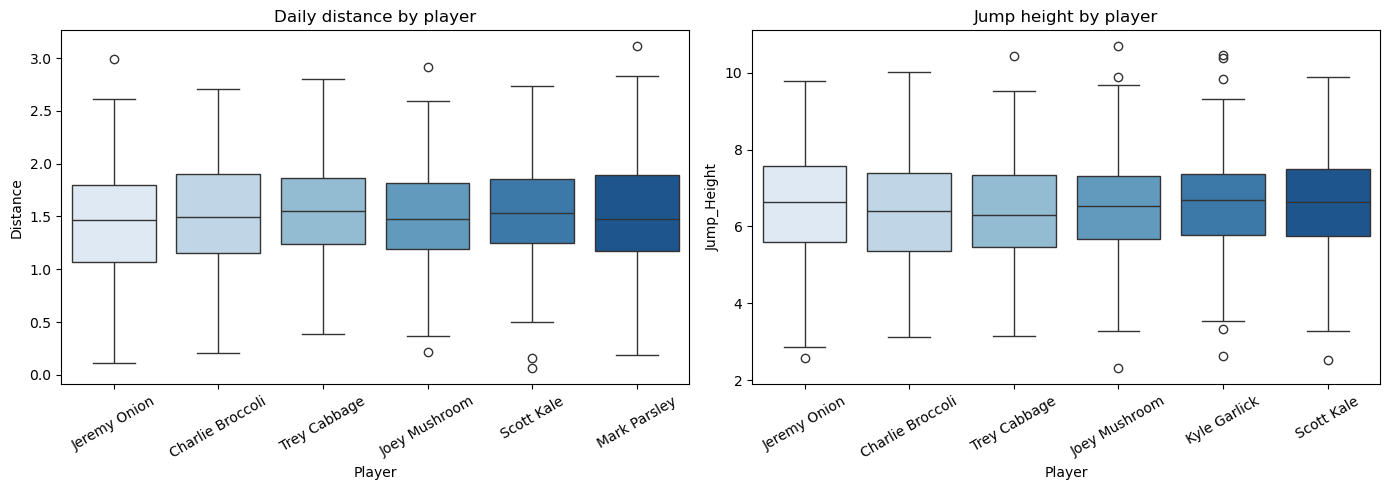

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=tracking, x="Player", y="Distance",
            hue="Player", legend=False, palette="Blues", ax=axes[0])
axes[0].set_title("Daily distance by player"); axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=force_plate, x="Player", y="Jump_Height",
            hue="Player", legend=False, palette="Blues", ax=axes[1])
axes[1].set_title("Jump height by player"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### Game vs. Practice context

tracking rows with no schedule match: 0


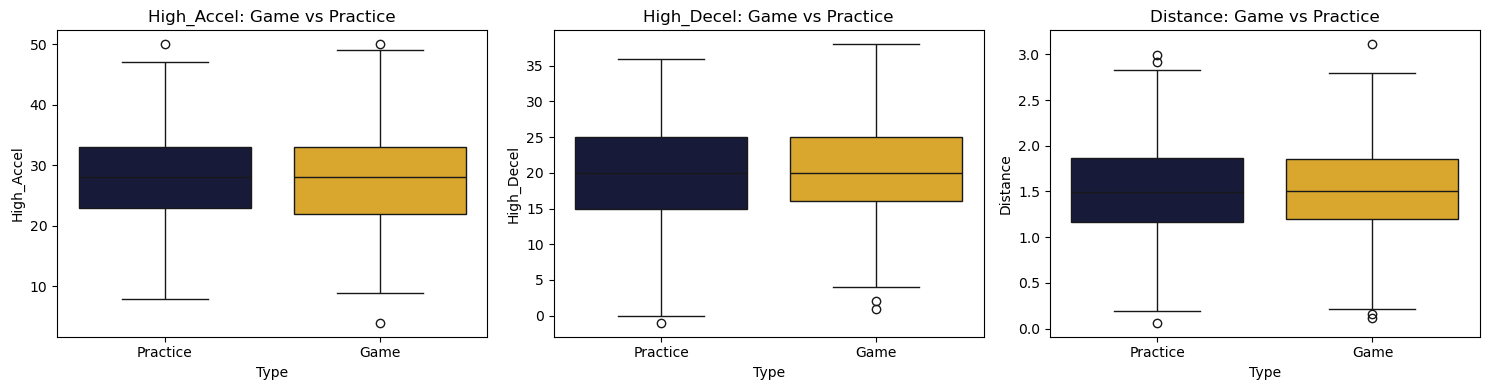

Mean by day type:
          High_Accel  High_Decel  Distance
Type                                      
Game           27.76       20.10      1.51
Practice       28.15       20.02      1.51


In [15]:
# Join the day-type context onto tracking (many player-days -> one schedule row per date).
trk_ctx = tracking.merge(schedule[["Date", "Type"]], on="Date", how="left")
print("tracking rows with no schedule match:", int(trk_ctx["Type"].isna().sum()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["High_Accel", "High_Decel", "Distance"]):
    sns.boxplot(data=trk_ctx, x="Type", y=col, hue="Type", legend=False,
                palette=["#12173E", "#F5B112"], ax=ax)
    ax.set_title(f"{col}: Game vs Practice")
plt.tight_layout(); plt.show()

print("Mean by day type:")
print(trk_ctx.groupby("Type")[["High_Accel", "High_Decel", "Distance"]].mean().round(2).to_string())

### Left vs. Right Leg

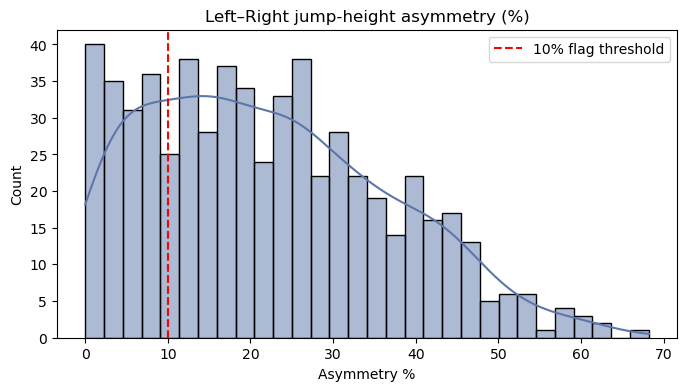

Tests above the 10% asymmetry flag: 75.0%

Mean asymmetry % by player:
Player
Jeremy Onion        24.1
Trey Cabbage        23.5
Charlie Broccoli    23.3
Joey Mushroom       20.8
Kyle Garlick        20.5
Scott Kale          19.8


In [16]:
# Reshape to one row per (player, date) with Left & Right side-by-side.
wide = force_plate.pivot_table(index=["Player", "Date"], columns="Leg", values="Jump_Height")
wide = wide.dropna(subset=["Left", "Right"])

# Asymmetry % relative to the stronger limb (a common Limb Symmetry Index form).
wide["asym_pct"] = (wide["Left"] - wide["Right"]).abs() / wide[["Left", "Right"]].max(axis=1) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(wide["asym_pct"], bins=30, kde=True, ax=ax, color="#5D76A9")
ax.axvline(10, color="red", ls="--", lw=1.5, label="10% flag threshold")
ax.set_title("Left–Right jump-height asymmetry (%)")
ax.set_xlabel("Asymmetry %"); ax.legend()
plt.show()

print(f"Tests above the 10% asymmetry flag: {(wide['asym_pct'] > 10).mean() * 100:.1f}%")
print("\nMean asymmetry % by player:")
print(wide.groupby("Player")["asym_pct"].mean().round(1).sort_values(ascending=False).to_string())

### Correlations between metrics

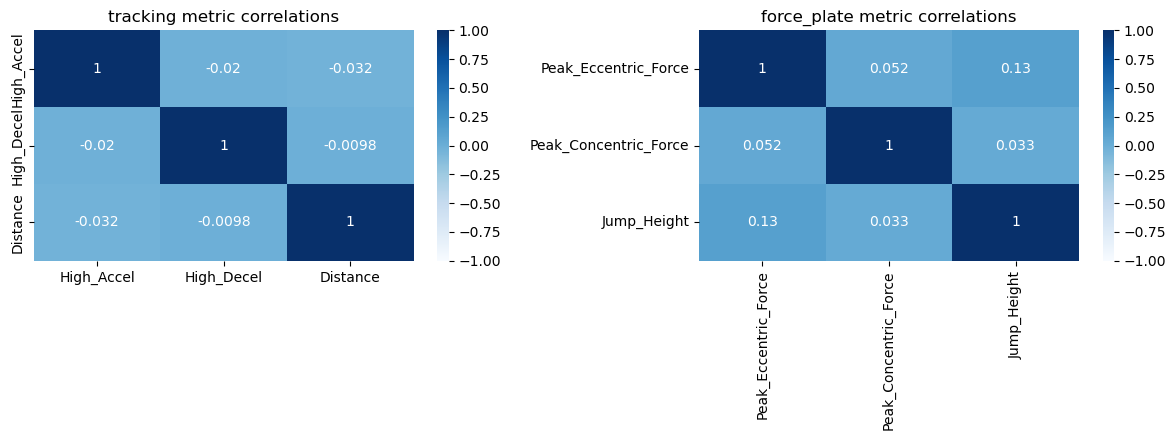

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(tracking[["High_Accel", "High_Decel", "Distance"]].corr(),
            annot=True, cmap="Blues", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("tracking metric correlations")
sns.heatmap(force_plate[["Peak_Eccentric_Force", "Peak_Concentric_Force", "Jump_Height"]].corr(),
            annot=True, cmap="Blues", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("force_plate metric correlations")
plt.tight_layout(); plt.show()

## 5. Notes and Findings

**Established Facts**
- 3 tables, one season (Oct 2023 – Jun 2024, incl. playoffs), all dates align across files.
- Grain: `tracking` = player-day; `force_plate` = player-day-leg; `schedule` = day (Game/Practice).
- 7 players total, but the rosters differ: Mark Parsley = tracking-only, Kyle Garlick = force-plate-only.
- No literal NaNs, but one `High_Decel = -1` value.
- Overall distributions are very normally distributed, very easy for standardization.
  - No crazy outliers
  - When divided by player, there are more individual outliers, but nothing that sticks out to raise major concern
- Game vs Practice explains much of the workload spread.
- Measurable Left/Right jump asymmetry exists. **Very** Right tailed distribution.
  - Research from sources show that a 10% difference in left to right should be classified as asymmetrical, therefore flagged for possible injury risk
    - A large portion of our data is asymmetrical
- None of our variables are remotely correlated to each other. Good for multicolinearity, each variable is responsible for an added dimensionality to our data

# Appendix:

**(Claude Generated)**

Quick scan of how sports-science groups build comparable tools, used to shape the ideas above.

**Sources**
- VALD — NBA profiling & monitoring: https://valdperformance.com/news/nba-profiling-monitoring-joey-davey
- VALD — Understanding the Countermovement Jump: https://valdperformance.com/news/understanding-the-countermovement-jump
- Catapult — What is Player Load: https://support.catapultsports.com/hc/en-us/articles/360000510795-What-is-Player-Load
- Kinexon — Elite basketball tracking: https://kinexon-sports.com/sports/basketball/
- Science for Sport — Acute:Chronic Workload Ratio: https://www.scienceforsport.com/acutechronic-workload-ratio/
- ACWR systematic review/meta-analysis (PMC): https://pmc.ncbi.nlm.nih.gov/articles/PMC12487117/
- Fusion Sport — Traffic-light systems: https://www.fusionsport.com/blog/traffic-light-systems-tips-tricks/
- "Does the 10% Asymmetry Threshold Matter?" (basketball, PMC): https://www.ncbi.nlm.nih.gov/pmc/articles/PMC12641735/
- Athlete Monitoring Systems in Elite Men's Basketball (Wiley, 2024): https://onlinelibrary.wiley.com/doi/full/10.1155/2024/6326566